# PyTorch 환경 확인

In [95]:
import torch

print('PyTorch:', torch.__version__); 
print('CUDA 사용 가능:', torch.cuda.is_available()); 
print('GPU:', torch.cuda.get_device_name(0))

# ultralytics.checks()

PyTorch: 2.6.0+cu124
CUDA 사용 가능: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [97]:
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

In [98]:
# 1. 재현성 고정
torch.manual_seed(1)

# 2. 데이터 로드
iris = load_iris()
X = iris.data
y = iris.target

X.shape, y.shape

((150, 4), (150,))

In [99]:
# 3. train/test 분할

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

In [100]:
# 4. X 스케일링

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [101]:
# 5. Tensor 변환

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# Dataset / DataLoader
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=15, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=15, shuffle=True)

In [102]:
# 7. 신경망 모델 정의

class IrisNet(nn.Module) :
    def __init__(self) : # 신경모델망 생성자
        super().__init__()
        self.fc1 = nn.Linear(4,16)   # 입력특성 4개
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16,3)   # 출력 클래스 3개
        
    def forward(self, x) :  # 순방향 학습
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        
        return x

In [103]:
model = IrisNet()
model

IrisNet(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=3, bias=True)
)

In [104]:
# 7-2. GPU 사용 설정

# 1. 장치 설정 (GPU가 있으면 'cuda', 없으면 'cpu')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. 모델을 해당 장치로 이동
model = model.to(device)

In [105]:
# 8. 손실함수와 Optimaizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01) # lr 학습률

In [ ]:
# 9. 학습 Loop
num_epochs = 100
loss_history = []

for epoch in range(num_epochs) :
    
    model.train()           # 학습
    running_loss = 0
    
    for x_batch, y_batch in train_loader :
        # GPU로 데이터 보내기
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch.long())
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    epoch_loss = running_loss / len(train_loader) 
    loss_history.append(epoch_loss)
    
    if (epoch + 1) % 10 == 0 :
        print(f"Epoch [{epoch+1}/{num_epochs}], loss: {epoch_loss:.4f}")

Epoch [10/100], loss: 0.2172
Epoch [20/100], loss: 0.1026
Epoch [30/100], loss: 0.0732
Epoch [40/100], loss: 0.0641
Epoch [50/100], loss: 0.0606
Epoch [60/100], loss: 0.0564
Epoch [70/100], loss: 0.0523
Epoch [80/100], loss: 0.0514
Epoch [90/100], loss: 0.0501
Epoch [100/100], loss: 0.0484


In [ ]:
# 10. 평가
model.eval()

correct = 0
total = 0

with torch.no_grad() :
    for x_batch, y_batch in test_loader :
        # GPU로 데이터 보내기
        x_batch = x_batch.to(device) 
        y_batch = y_batch.to(device) 
        
        outputs = model(x_batch)
        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted==y_batch).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy : {accuracy:.2f}%")

Test Accuracy : 97.78%


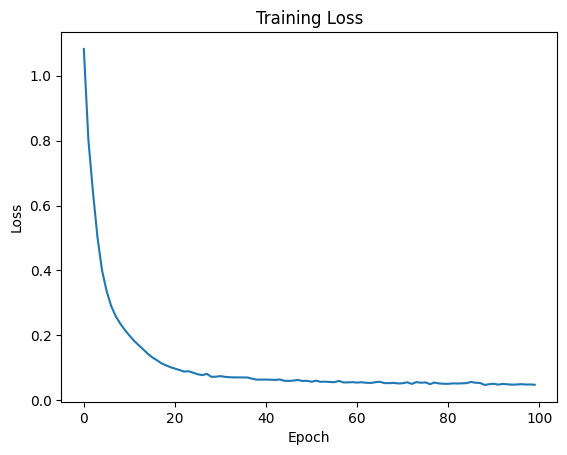

In [108]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.title('Training Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()